# Ansiedad / Depresion — 2D Espectrogramas | Servidor PyTorch CUDA
**Validacion:** Repeated Stratified 5-Fold x 5 repeticiones = 25 folds

**Rutas:** `Clasificacion Final/Ansiedad/specs/{dur}s/{0,1}/*.png`

**Modelos:** CNN-2D propia · ResNet-50 · VGG-19 · EfficientNet-B0

Para Depresion: cambiar `CONDITION`, `IMAGE_ROOT` `OUT_DIR` en cada celda.


# CNN-2D

## 10 s | Sin overlap

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/CNN2D/10s
  Modelo : CNN-2D | 10s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 1,813  |  prom 22.9 segs/audio
  Guardando resultados en: Ansiedad/CNN2D/10s

INICIANDO REPEATED CV — CNN-2D | 10s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 2,213
  Parametros entrenables: 3,725,601

  Ep 01/30 loss 0.6970  best 0.6970  ✓
  Ep 02/30 loss 0.6892  best 0.6892  ✓
  Ep 03/30 loss 0.6810  best 0.6810  ✓
  Ep 04/30 loss 0.6813  best 0.6810  (1/5)
  Ep 05/30 loss 0.6798  best 0.6798  ✓
  Ep 06/30 loss 0.6775  best 0.6775  ✓
  Ep 07/30 loss 0.6688  best 0.6688  ✓
  Ep 08/30 loss 0.6654  best 0.6654  ✓
  Ep 09/30 loss 0.6545  best 0.6545  ✓
  Ep 10/30 loss 0.6484

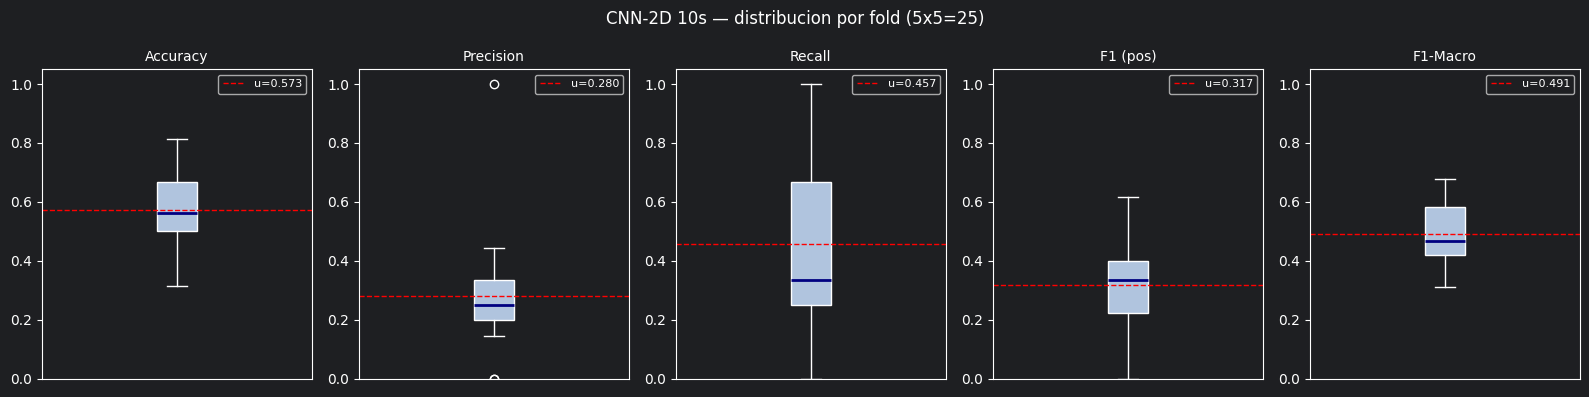

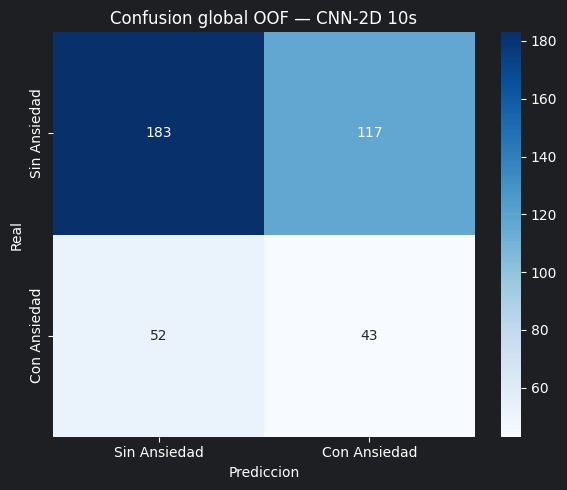

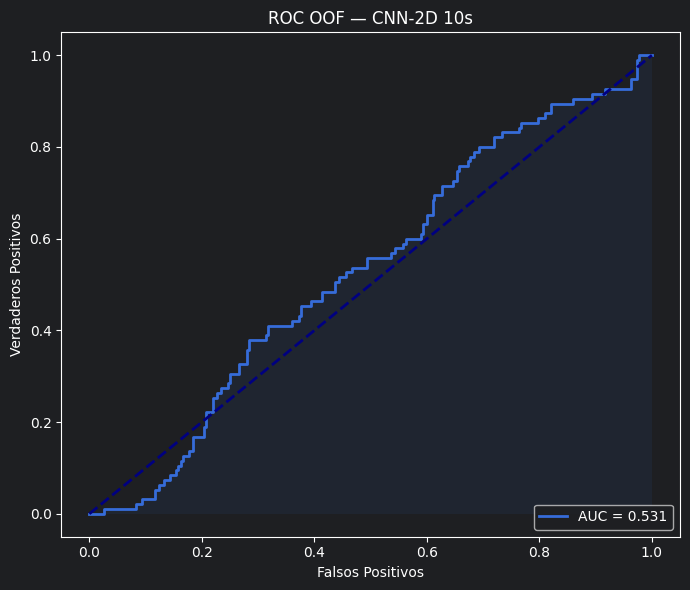

Archivos guardados en: Ansiedad/CNN2D/10s


In [3]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  CNN-2D — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 10s | 0% (sin overlap)
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/10s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 10
BATCH_SIZE  = 128
EPOCHS      = 30
IMG_H       = 128
IMG_W       = 128

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

class CNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_ch, out_ch, n=2):
            layers = []
            for i in range(n):
                layers += [nn.Conv2d(in_ch if i==0 else out_ch, out_ch, 3, padding=1),
                           nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers, nn.MaxPool2d(2), nn.Dropout2d(0.2))
        self.features = nn.Sequential(
            conv_block(3,   32,  n=2),
            conv_block(32,  64,  n=2),
            conv_block(64,  128, n=3),
            conv_block(128, 256, n=3),
            conv_block(256, 256, n=3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64,    1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)

def build_model(): return CNN2D()



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")


## 2 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/CNN2D/2s
  Modelo : CNN-2D | 2s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 18,369  |  prom 232.5 segs/audio
  Guardando resultados en: Ansiedad/CNN2D/2s

INICIANDO REPEATED CV — CNN-2D | 2s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 23,098
  Parametros entrenables: 3,725,601

  Ep 01/30 loss 0.6825  best 0.6825  ✓
  Ep 02/30 loss 0.6317  best 0.6317  ✓
  Ep 03/30 loss 0.5623  best 0.5623  ✓
  Ep 04/30 loss 0.5054  best 0.5054  ✓
  Ep 05/30 loss 0.4569  best 0.4569  ✓
  Ep 06/30 loss 0.4070  best 0.4070  ✓
  Ep 07/30 loss 0.3477  best 0.3477  ✓
  Ep 08/30 loss 0.2860  best 0.2860  ✓
  Ep 09/30 loss 0.2372  best 0.2372  ✓
  Ep 10/30 loss 0.2083  bes

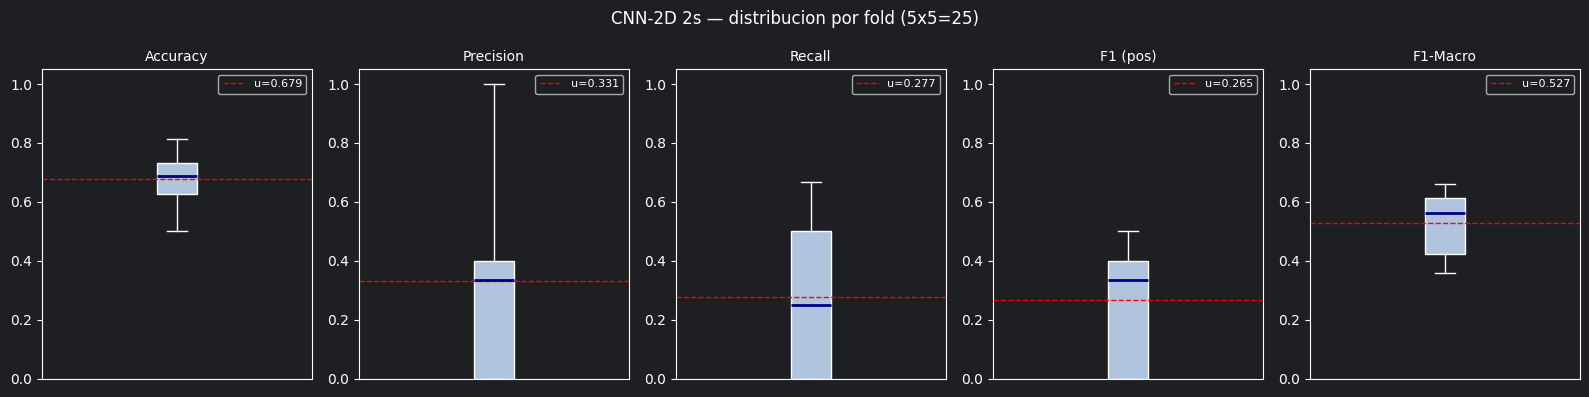

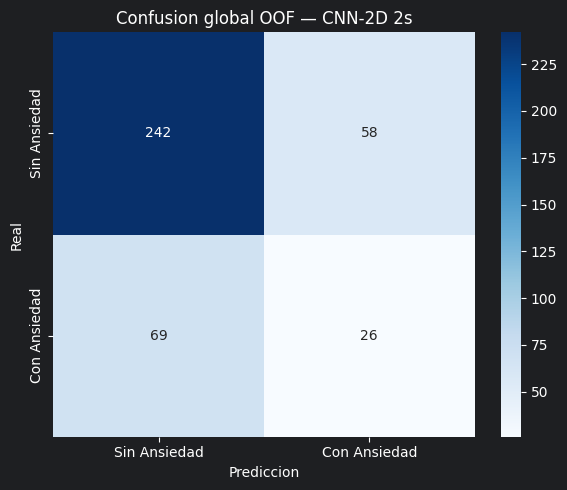

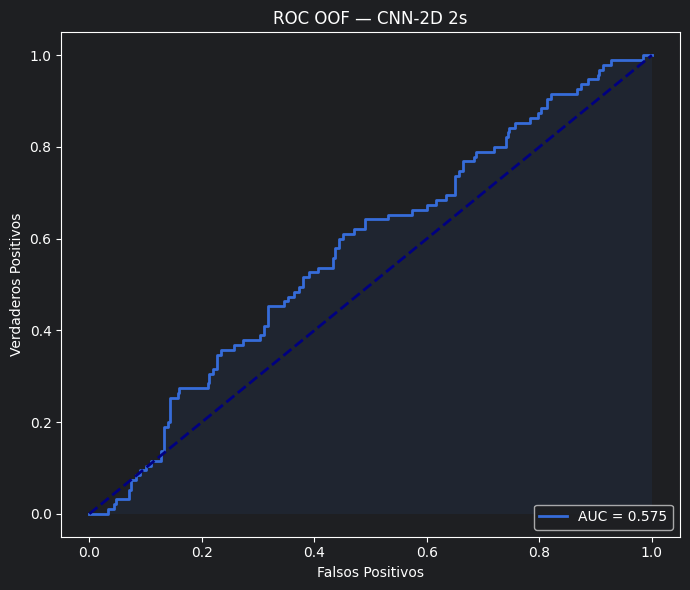

Archivos guardados en: Ansiedad/CNN2D/2s


In [4]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  CNN-2D — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 2s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/2s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 2
BATCH_SIZE  = 128
EPOCHS      = 30
IMG_H       = 128
IMG_W       = 128

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

class CNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_ch, out_ch, n=2):
            layers = []
            for i in range(n):
                layers += [nn.Conv2d(in_ch if i==0 else out_ch, out_ch, 3, padding=1),
                           nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers, nn.MaxPool2d(2), nn.Dropout2d(0.2))
        self.features = nn.Sequential(
            conv_block(3,   32,  n=2),
            conv_block(32,  64,  n=2),
            conv_block(64,  128, n=3),
            conv_block(128, 256, n=3),
            conv_block(256, 256, n=3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64,    1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)

def build_model(): return CNN2D()



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 3 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/CNN2D/3s
  Modelo : CNN-2D | 3s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 12,202  |  prom 154.5 segs/audio
  Guardando resultados en: Ansiedad/CNN2D/3s

INICIANDO REPEATED CV — CNN-2D | 3s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 15,214
  Parametros entrenables: 3,725,601

  Ep 01/30 loss 0.6937  best 0.6937  ✓
  Ep 02/30 loss 0.6846  best 0.6846  ✓
  Ep 03/30 loss 0.6586  best 0.6586  ✓
  Ep 04/30 loss 0.5932  best 0.5932  ✓
  Ep 05/30 loss 0.5287  best 0.5287  ✓
  Ep 06/30 loss 0.4788  best 0.4788  ✓
  Ep 07/30 loss 0.4293  best 0.4293  ✓
  Ep 08/30 loss 0.3744  best 0.3744  ✓
  Ep 09/30 loss 0.3169  best 0.3169  ✓
  Ep 10/30 loss 0.2643  bes

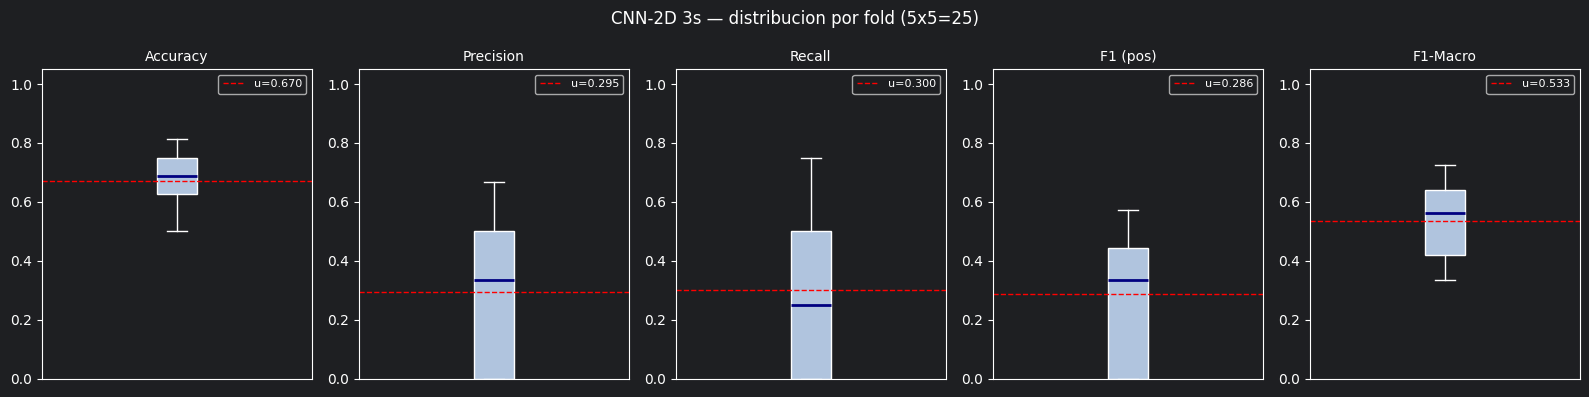

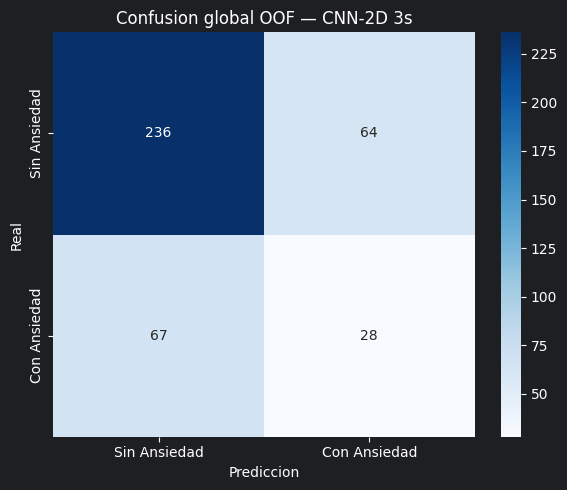

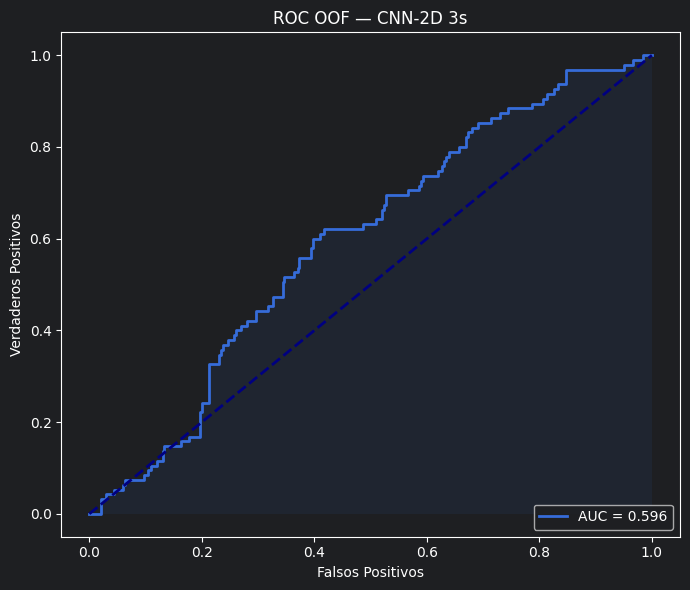

Archivos guardados en: Ansiedad/CNN2D/3s


In [5]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  CNN-2D — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 3s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/3s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 3
BATCH_SIZE  = 128
EPOCHS      = 30
IMG_H       = 128
IMG_W       = 128

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

class CNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_ch, out_ch, n=2):
            layers = []
            for i in range(n):
                layers += [nn.Conv2d(in_ch if i==0 else out_ch, out_ch, 3, padding=1),
                           nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers, nn.MaxPool2d(2), nn.Dropout2d(0.2))
        self.features = nn.Sequential(
            conv_block(3,   32,  n=2),
            conv_block(32,  64,  n=2),
            conv_block(64,  128, n=3),
            conv_block(128, 256, n=3),
            conv_block(256, 256, n=3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64,    1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)

def build_model(): return CNN2D()



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 4 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/CNN2D/4s
  Modelo : CNN-2D | 4s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 9,127  |  prom 115.5 segs/audio
  Guardando resultados en: Ansiedad/CNN2D/4s

INICIANDO REPEATED CV — CNN-2D | 4s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 11,068
  Parametros entrenables: 3,725,601

  Ep 01/30 loss 0.6936  best 0.6936  ✓
  Ep 02/30 loss 0.6876  best 0.6876  ✓
  Ep 03/30 loss 0.6704  best 0.6704  ✓
  Ep 04/30 loss 0.6167  best 0.6167  ✓
  Ep 05/30 loss 0.5602  best 0.5602  ✓
  Ep 06/30 loss 0.5180  best 0.5180  ✓
  Ep 07/30 loss 0.4609  best 0.4609  ✓
  Ep 08/30 loss 0.4135  best 0.4135  ✓
  Ep 09/30 loss 0.3573  best 0.3573  ✓
  Ep 10/30 loss 0.3170  best

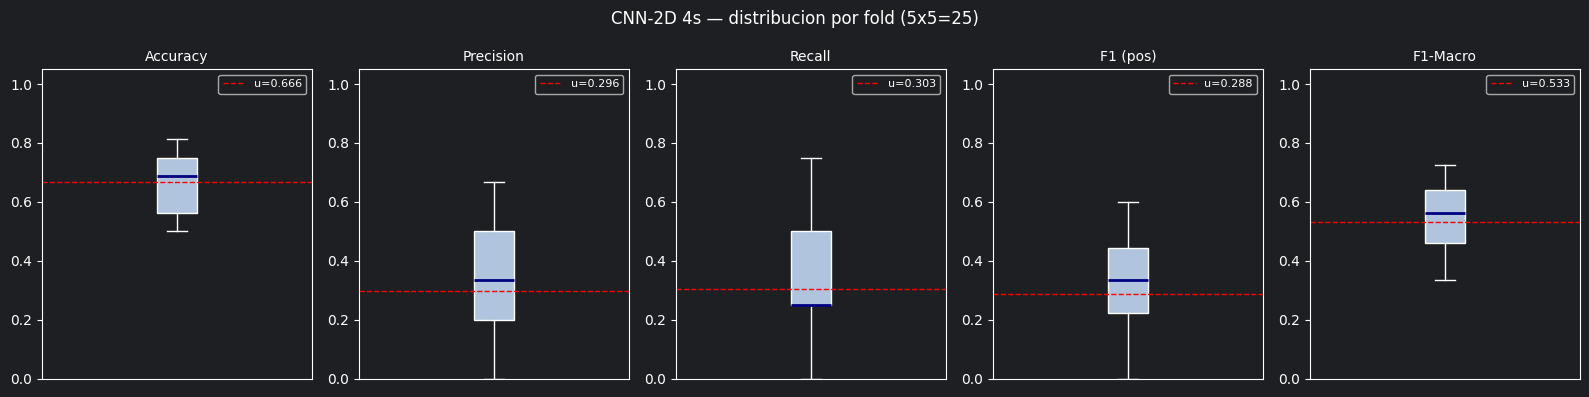

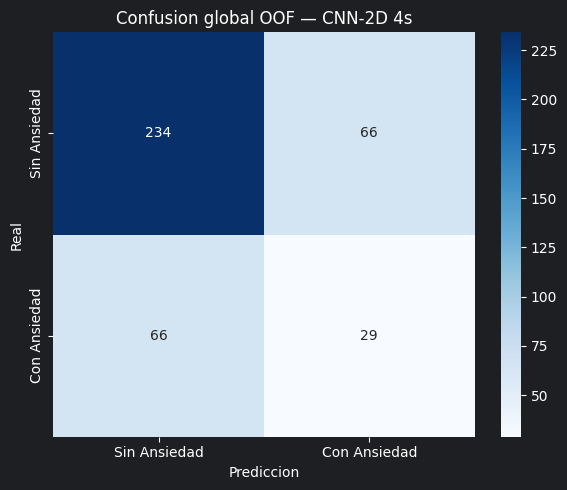

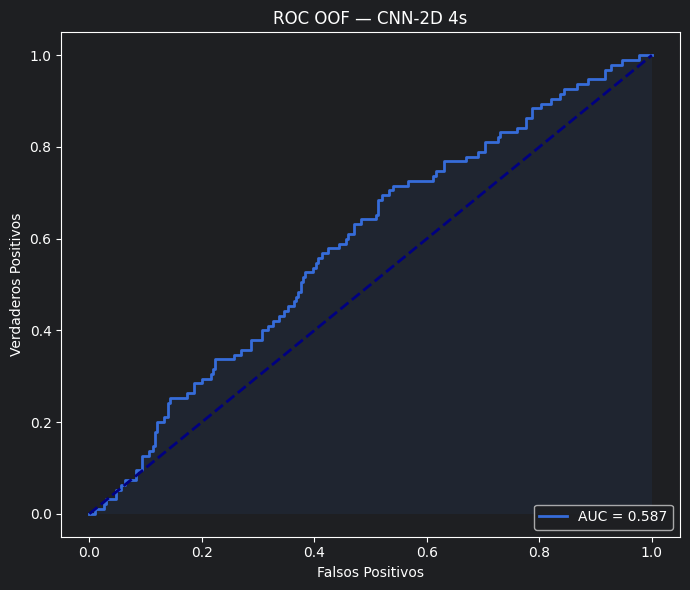

Archivos guardados en: Ansiedad/CNN2D/4s


In [6]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  CNN-2D — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 4s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/4s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 4
BATCH_SIZE  = 128
EPOCHS      = 30
IMG_H       = 128
IMG_W       = 128

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "CNN-2D"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("CNN2D/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

class CNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_ch, out_ch, n=2):
            layers = []
            for i in range(n):
                layers += [nn.Conv2d(in_ch if i==0 else out_ch, out_ch, 3, padding=1),
                           nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            return nn.Sequential(*layers, nn.MaxPool2d(2), nn.Dropout2d(0.2))
        self.features = nn.Sequential(
            conv_block(3,   32,  n=2),
            conv_block(32,  64,  n=2),
            conv_block(64,  128, n=3),
            conv_block(128, 256, n=3),
            conv_block(256, 256, n=3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(64,    1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)

def build_model(): return CNN2D()



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



# ResNet-50

## 10 s | Sin overlap

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/ResNet50/10s
  Modelo : ResNet-50 | 10s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 1,813  |  prom 22.9 segs/audio
  Guardando resultados en: Ansiedad/ResNet50/10s

INICIANDO REPEATED CV — ResNet-50 | 10s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 2,151
  Parametros entrenables: 24,032,833

  Ep 01/30 loss 0.6718  best 0.6718  ✓
  Ep 02/30 loss 0.4834  best 0.4834  ✓
  Ep 03/30 loss 0.2084  best 0.2084  ✓
  Ep 04/30 loss 0.0438  best 0.0438  ✓
  Ep 05/30 loss 0.0132  best 0.0132  ✓
  Ep 06/30 loss 0.0064  best 0.0064  ✓
  Ep 07/30 loss 0.0036  best 0.0036  ✓
  Ep 08/30 loss 0.0021  best 0.0021  ✓
  Ep 09/30 loss 0.0021  best 0.0021  (1/5)
  Ep 10/3

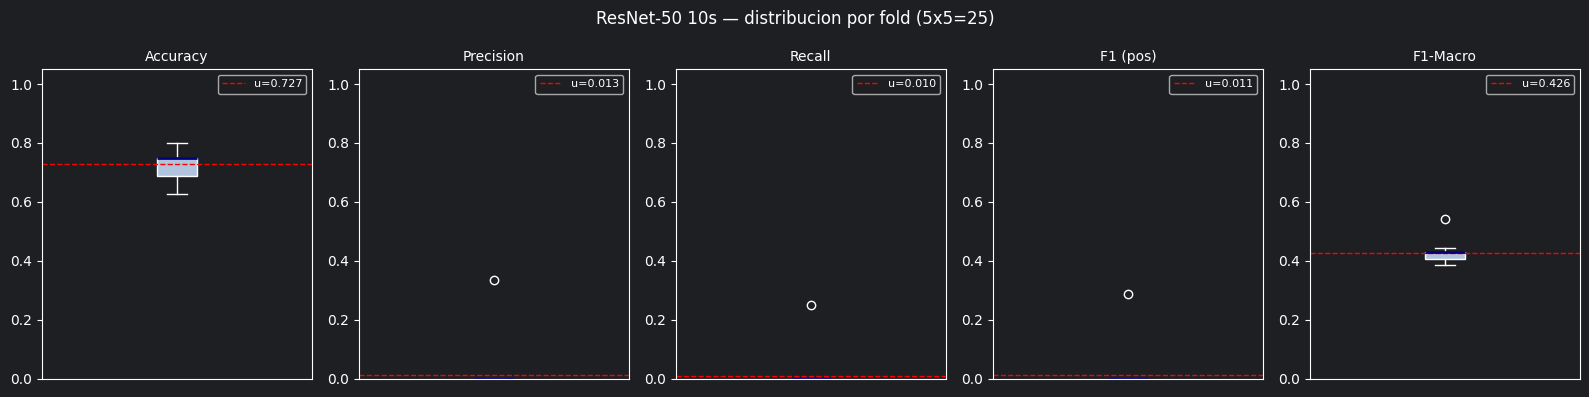

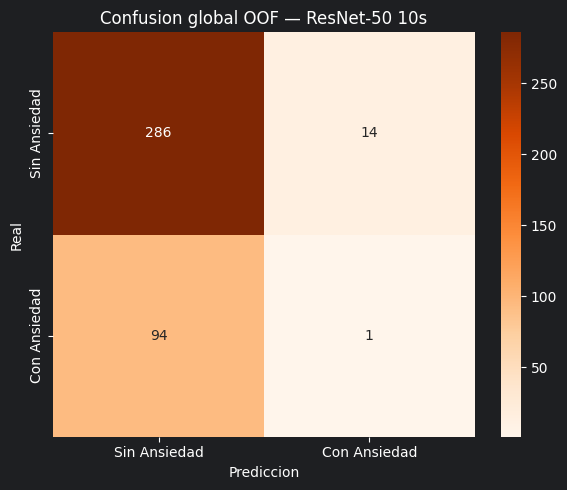

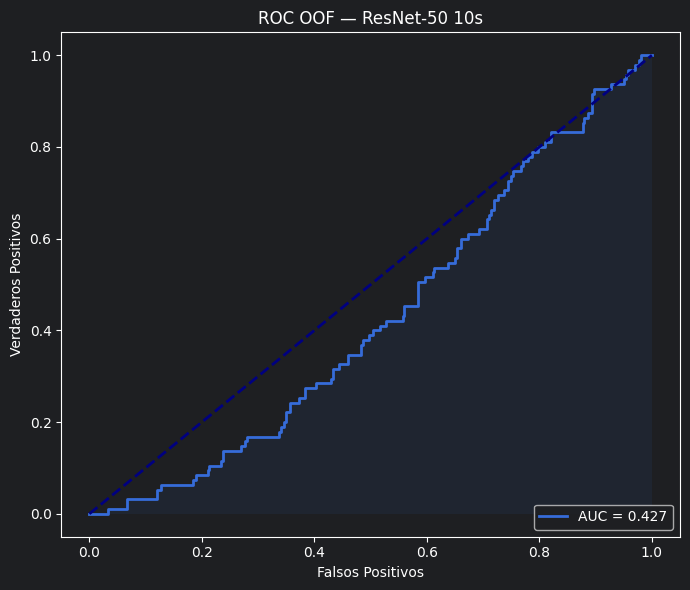

Archivos guardados en: Ansiedad/ResNet50/10s


In [7]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  ResNet-50 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 10s | 0% (sin overlap)
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/10s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 10
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 2 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/ResNet50/2s
  Modelo : ResNet-50 | 2s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 18,369  |  prom 232.5 segs/audio
  Guardando resultados en: Ansiedad/ResNet50/2s

INICIANDO REPEATED CV — ResNet-50 | 2s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 22,453
  Parametros entrenables: 24,032,833

  Ep 01/30 loss 0.4927  best 0.4927  ✓
  Ep 02/30 loss 0.1688  best 0.1688  ✓
  Ep 03/30 loss 0.0634  best 0.0634  ✓
  Ep 04/30 loss 0.0420  best 0.0420  ✓
  Ep 05/30 loss 0.0281  best 0.0281  ✓
  Ep 06/30 loss 0.0262  best 0.0262  ✓
  Ep 07/30 loss 0.0214  best 0.0214  ✓
  Ep 08/30 loss 0.0228  best 0.0214  (1/5)
  Ep 09/30 loss 0.0140  best 0.0140  ✓
  Ep 10/30

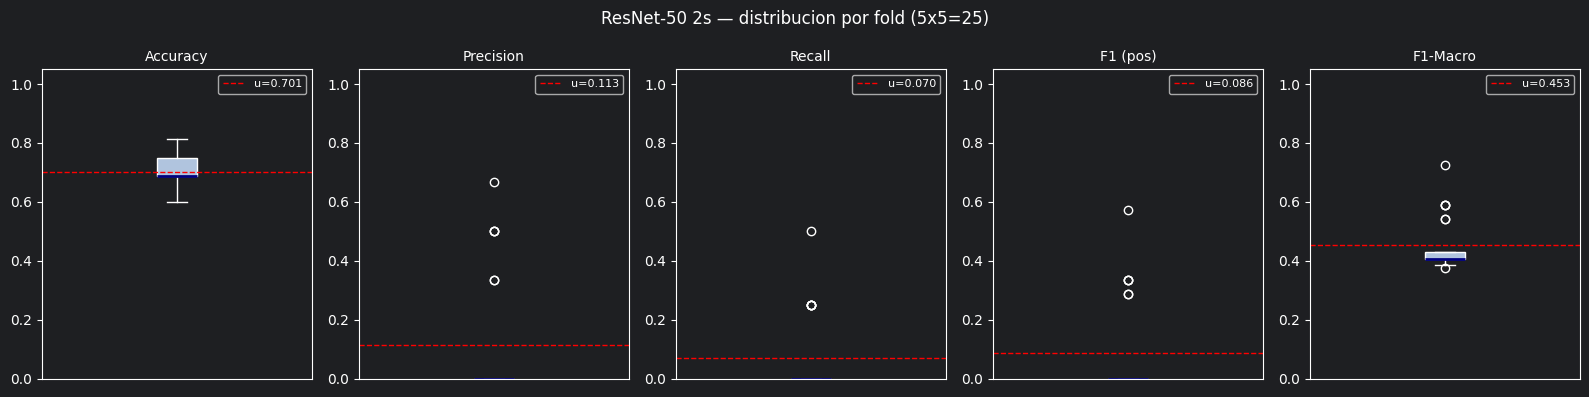

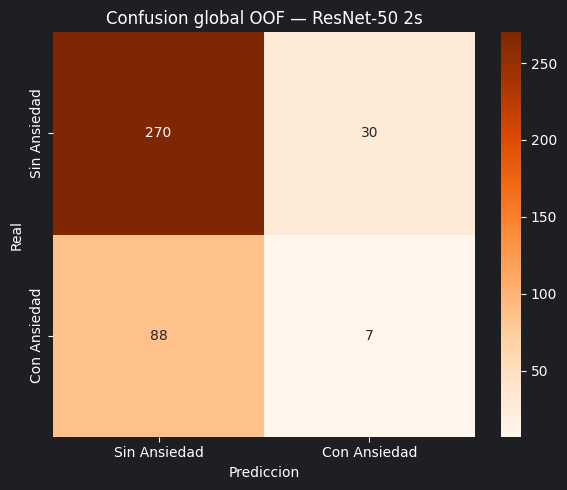

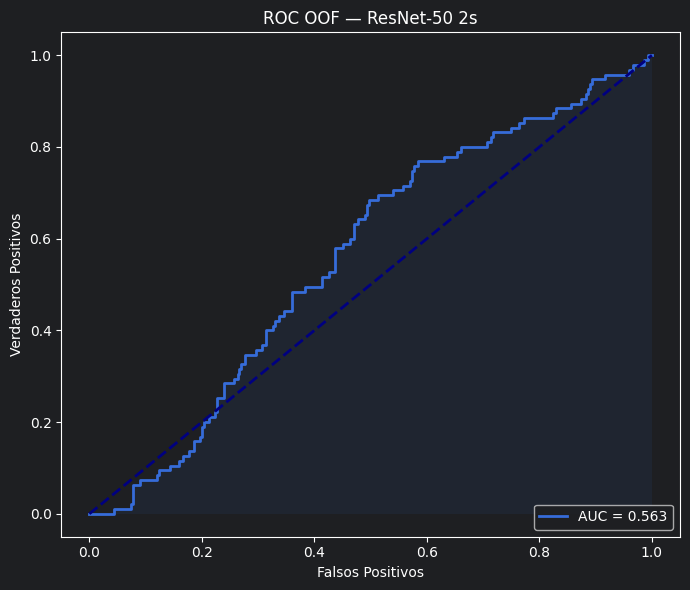

Archivos guardados en: Ansiedad/ResNet50/2s


In [8]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  ResNet-50 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 2s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/2s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 2
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 3 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/ResNet50/3s
  Modelo : ResNet-50 | 3s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 12,202  |  prom 154.5 segs/audio
  Guardando resultados en: Ansiedad/ResNet50/3s

INICIANDO REPEATED CV — ResNet-50 | 3s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 15,020
  Parametros entrenables: 24,032,833

  Ep 01/30 loss 0.5118  best 0.5118  ✓
  Ep 02/30 loss 0.1480  best 0.1480  ✓
  Ep 03/30 loss 0.0465  best 0.0465  ✓
  Ep 04/30 loss 0.0314  best 0.0314  ✓
  Ep 05/30 loss 0.0164  best 0.0164  ✓
  Ep 06/30 loss 0.0191  best 0.0164  (1/5)
  Ep 07/30 loss 0.0193  best 0.0164  (2/5)
  Ep 08/30 loss 0.0270  best 0.0164  (3/5)
  Ep 09/30 loss 0.0116  best 0.0116  ✓
  

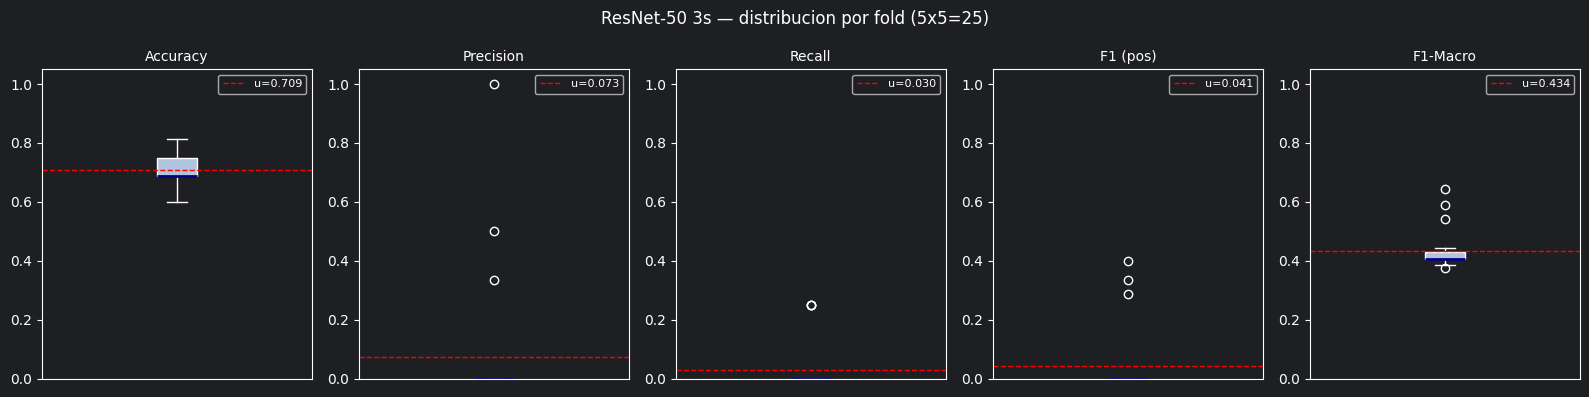

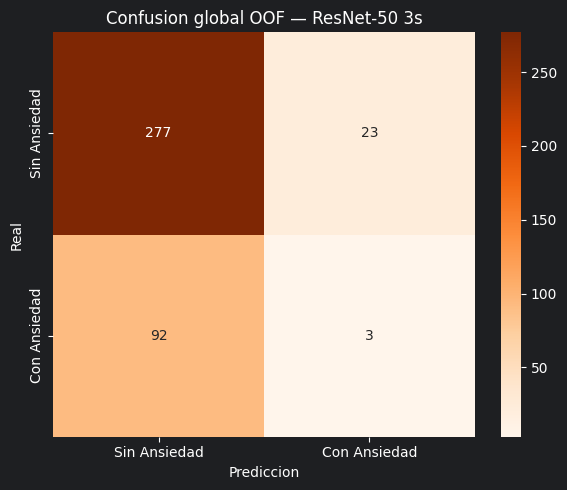

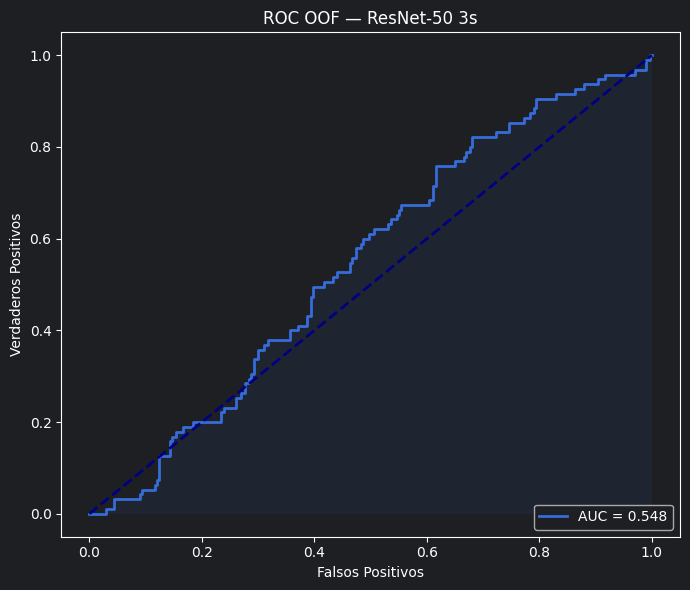

Archivos guardados en: Ansiedad/ResNet50/3s


In [9]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  ResNet-50 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 3s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/3s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 3
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 4 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/ResNet50/4s
  Modelo : ResNet-50 | 4s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 9,127  |  prom 115.5 segs/audio
  Guardando resultados en: Ansiedad/ResNet50/4s

INICIANDO REPEATED CV — ResNet-50 | 4s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 11,287
  Parametros entrenables: 24,032,833

  Ep 01/30 loss 0.5235  best 0.5235  ✓
  Ep 02/30 loss 0.1405  best 0.1405  ✓
  Ep 03/30 loss 0.0371  best 0.0371  ✓
  Ep 04/30 loss 0.0222  best 0.0222  ✓
  Ep 05/30 loss 0.0216  best 0.0216  ✓
  Ep 06/30 loss 0.0291  best 0.0216  (1/5)
  Ep 07/30 loss 0.0128  best 0.0128  ✓
  Ep 08/30 loss 0.0110  best 0.0110  ✓
  Ep 09/30 loss 0.0126  best 0.0110  (1/5)
  Ep 10

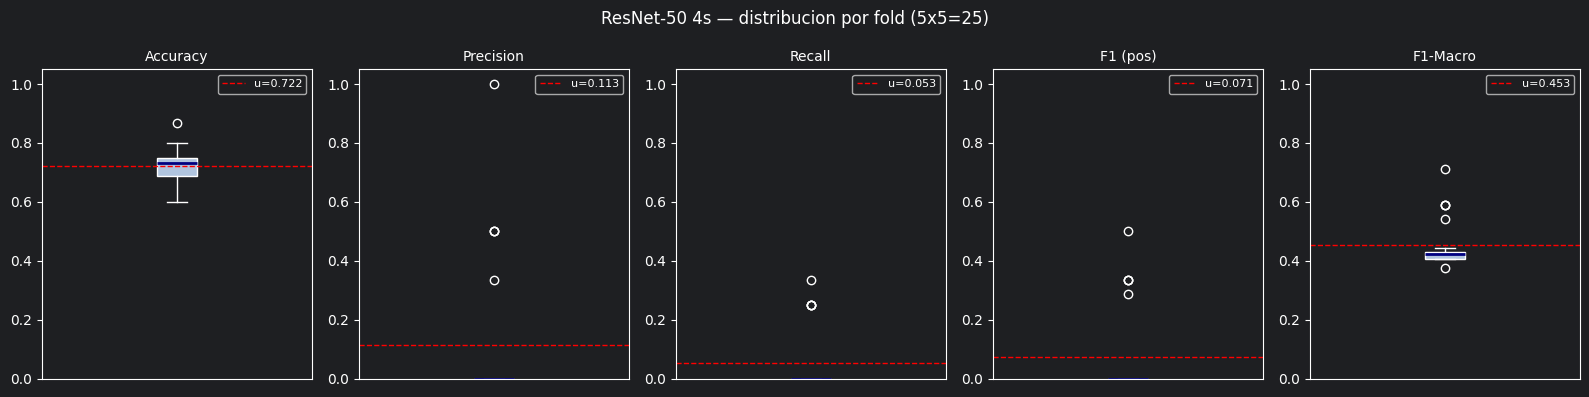

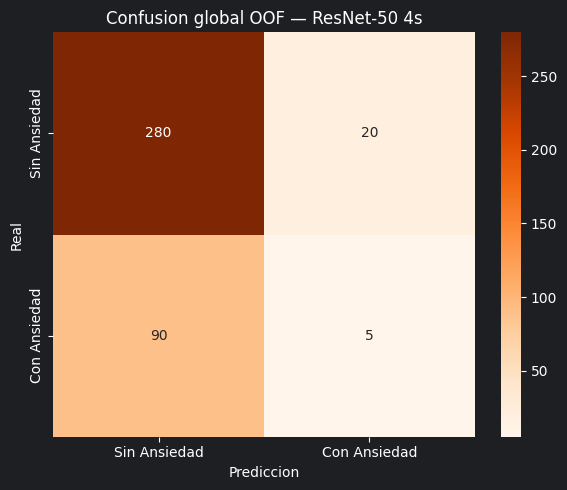

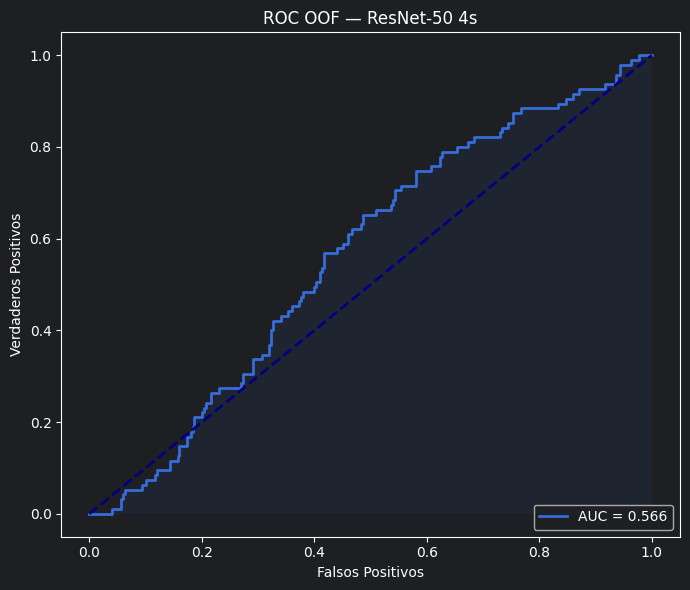

Archivos guardados en: Ansiedad/ResNet50/4s


In [10]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  ResNet-50 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 4s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/4s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 4
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "ResNet-50"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("ResNet50/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



# VGG-19

## 10 s | Sin overlap

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/VGG19/10s
  Modelo : VGG-19 | 10s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 1,813  |  prom 22.9 segs/audio
  Guardando resultados en: Ansiedad/VGG19/10s

INICIANDO REPEATED CV — VGG-19 | 10s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 2,235
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /home/ci2dt2-ai/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:10<00:00, 52.4MB/s] 


  Parametros entrenables: 32,946,753

  Ep 01/30 loss 0.5896  best 0.5896  ✓
  Ep 02/30 loss 0.1219  best 0.1219  ✓
  Ep 03/30 loss 0.0256  best 0.0256  ✓
  Ep 04/30 loss 0.0043  best 0.0043  ✓
  Ep 05/30 loss 0.0009  best 0.0009  ✓
  Ep 06/30 loss 0.0004  best 0.0004  ✓
  Ep 07/30 loss 0.0003  best 0.0003  ✓
  Ep 08/30 loss 0.0002  best 0.0002  ✓
  Ep 09/30 loss 0.0002  best 0.0002  ✓
  Ep 10/30 loss 0.0001  best 0.0001  ✓
  Ep 11/30 loss 0.0001  best 0.0001  ✓
  Ep 12/30 loss 0.0001  best 0.0001  ✓
  Ep 13/30 loss 0.0001  best 0.0001  ✓
  Ep 14/30 loss 0.0001  best 0.0001  ✓
  Ep 15/30 loss 0.0001  best 0.0001  ✓
  Ep 16/30 loss 0.0001  best 0.0001  (1/5)
  Ep 17/30 loss 0.0001  best 0.0001  (2/5)
  Ep 18/30 loss 0.0001  best 0.0001  ✓
  Ep 19/30 loss 0.0000  best 0.0000  ✓
  Ep 20/30 loss 0.0000  best 0.0000  ✓
  Ep 21/30 loss 0.0000  best 0.0000  ✓
  Ep 22/30 loss 0.0000  best 0.0000  ✓
  Ep 23/30 loss 0.0000  best 0.0000  (1/5)
  Ep 24/30 loss 0.0000  best 0.0000  ✓
  Ep 25/30 los

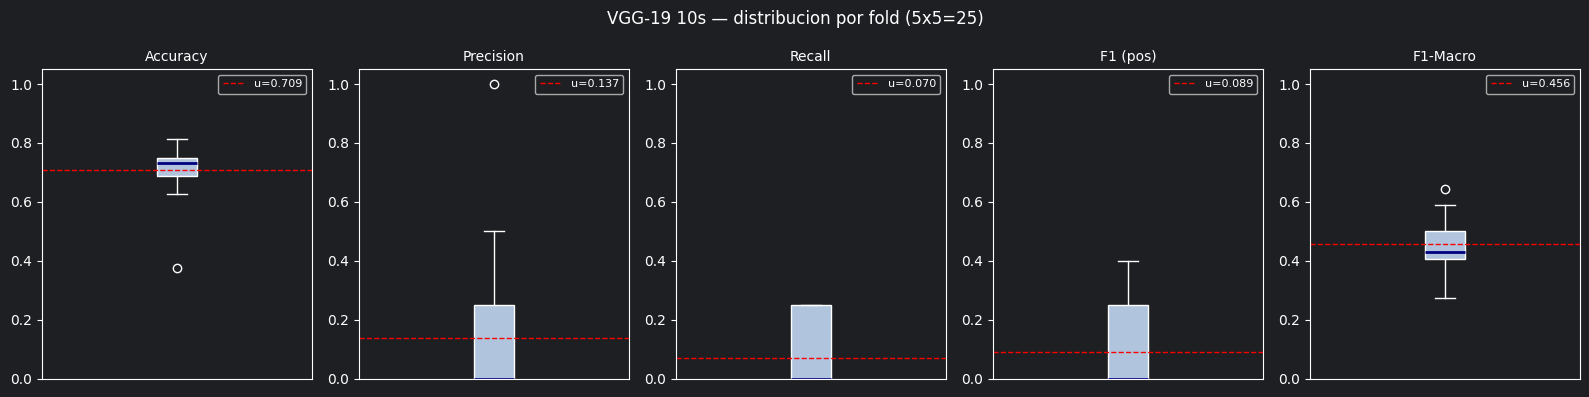

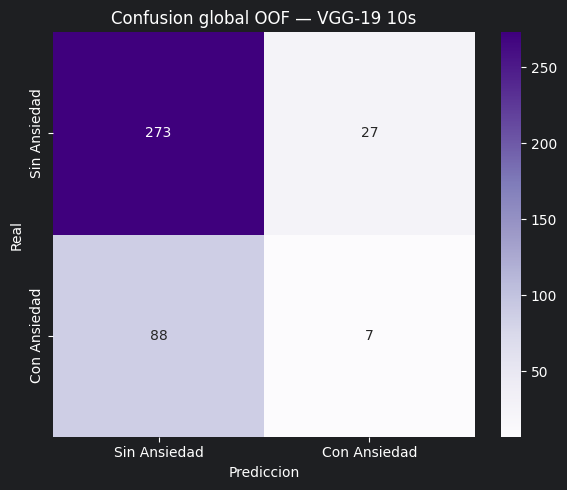

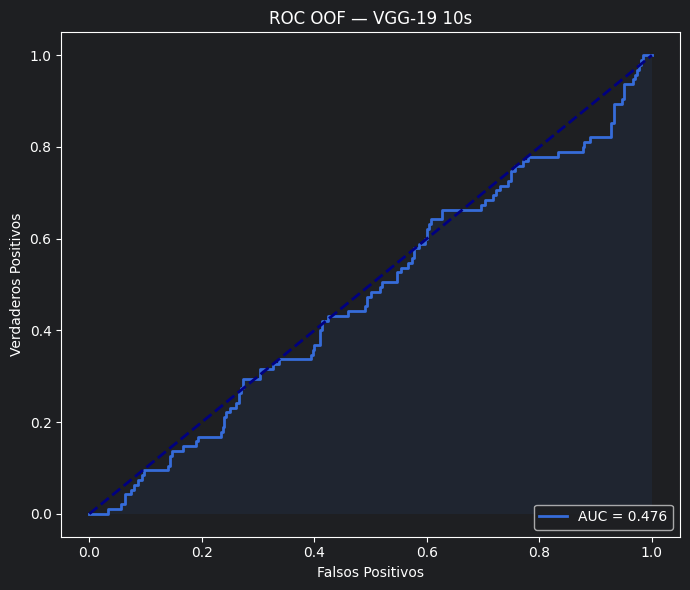

Archivos guardados en: Ansiedad/VGG19/10s


In [11]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  VGG-19 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 10s | 0% (sin overlap)
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/10s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 10
BATCH_SIZE  = 64
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.vgg19_bn(weights=tv_models.VGG19_BN_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Linear(m.classifier[0].in_features, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 2 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/VGG19/2s
  Modelo : VGG-19 | 2s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 18,369  |  prom 232.5 segs/audio
  Guardando resultados en: Ansiedad/VGG19/2s

INICIANDO REPEATED CV — VGG-19 | 2s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 23,141
  Parametros entrenables: 32,946,753

  Ep 01/30 loss 0.3788  best 0.3788  ✓
  Ep 02/30 loss 0.1192  best 0.1192  ✓
  Ep 03/30 loss 0.0552  best 0.0552  ✓
  Ep 04/30 loss 0.0317  best 0.0317  ✓
  Ep 05/30 loss 0.0256  best 0.0256  ✓
  Ep 06/30 loss 0.0228  best 0.0228  ✓
  Ep 07/30 loss 0.0171  best 0.0171  ✓
  Ep 08/30 loss 0.0180  best 0.0171  (1/5)
  Ep 09/30 loss 0.0120  best 0.0120  ✓
  Ep 10/30 loss 0.0177

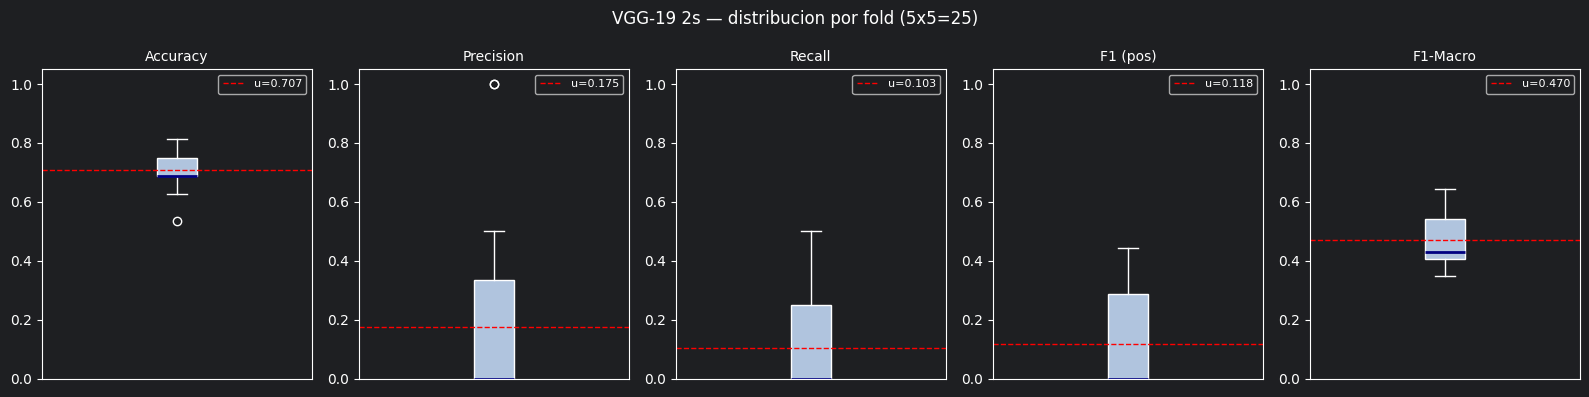

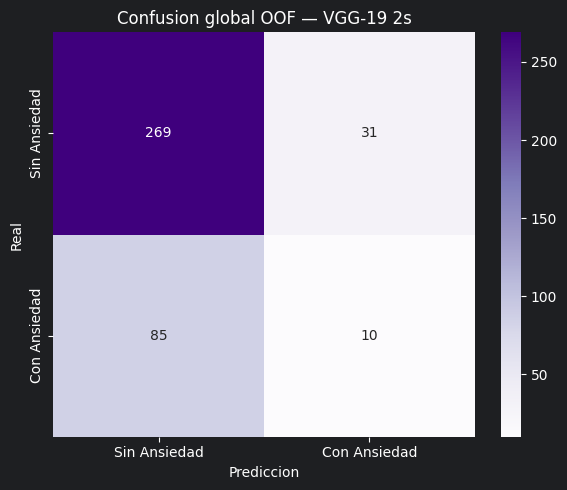

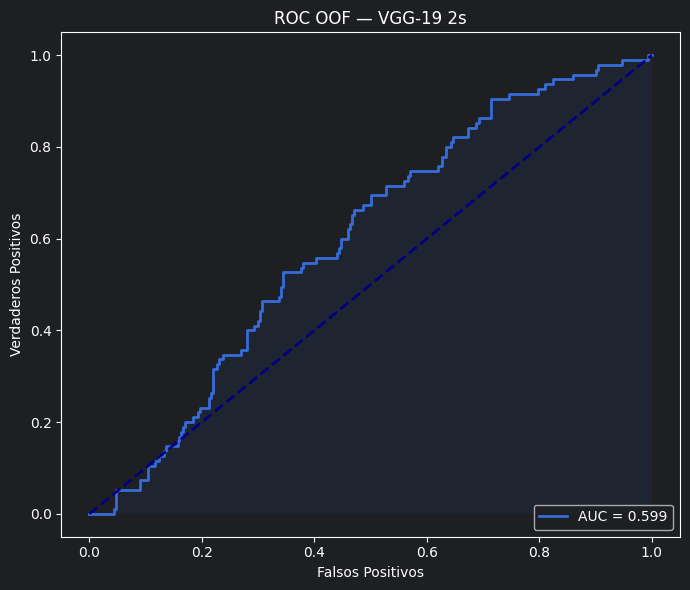

Archivos guardados en: Ansiedad/VGG19/2s


In [12]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  VGG-19 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 2s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/2s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 2
BATCH_SIZE  = 64
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.vgg19_bn(weights=tv_models.VGG19_BN_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Linear(m.classifier[0].in_features, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 3 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/VGG19/3s
  Modelo : VGG-19 | 3s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 12,202  |  prom 154.5 segs/audio
  Guardando resultados en: Ansiedad/VGG19/3s

INICIANDO REPEATED CV — VGG-19 | 3s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 14,894
  Parametros entrenables: 32,946,753

  Ep 01/30 loss 0.3819  best 0.3819  ✓
  Ep 02/30 loss 0.0970  best 0.0970  ✓
  Ep 03/30 loss 0.0431  best 0.0431  ✓
  Ep 04/30 loss 0.0288  best 0.0288  ✓
  Ep 05/30 loss 0.0241  best 0.0241  ✓
  Ep 06/30 loss 0.0153  best 0.0153  ✓
  Ep 07/30 loss 0.0190  best 0.0153  (1/5)
  Ep 08/30 loss 0.0156  best 0.0153  (2/5)
  Ep 09/30 loss 0.0093  best 0.0093  ✓
  Ep 10/30 loss 0.

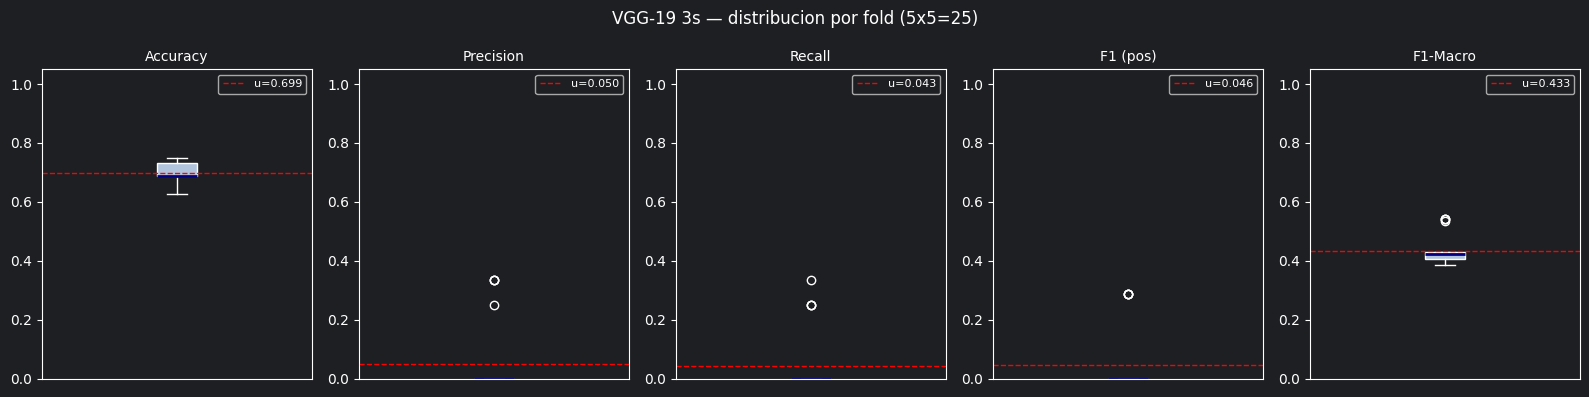

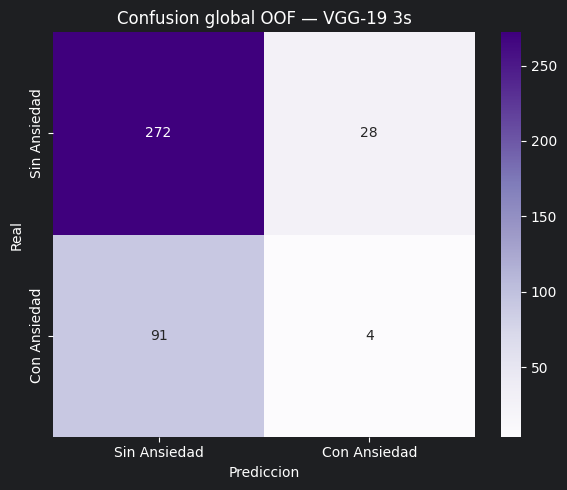

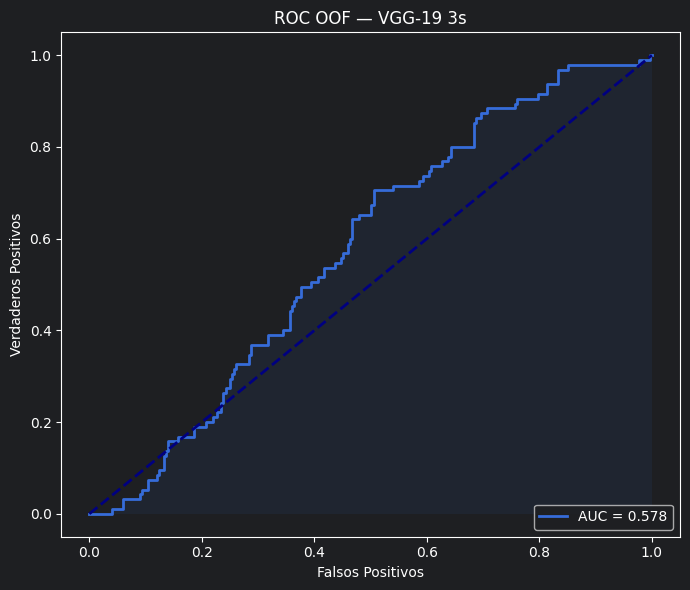

Archivos guardados en: Ansiedad/VGG19/3s


In [13]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  VGG-19 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 3s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/3s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 3
BATCH_SIZE  = 64
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.vgg19_bn(weights=tv_models.VGG19_BN_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Linear(m.classifier[0].in_features, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 4 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/VGG19/4s
  Modelo : VGG-19 | 4s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 9,127  |  prom 115.5 segs/audio
  Guardando resultados en: Ansiedad/VGG19/4s

INICIANDO REPEATED CV — VGG-19 | 4s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 11,190
  Parametros entrenables: 32,946,753

  Ep 01/30 loss 0.4170  best 0.4170  ✓
  Ep 02/30 loss 0.1270  best 0.1270  ✓
  Ep 03/30 loss 0.0503  best 0.0503  ✓
  Ep 04/30 loss 0.0281  best 0.0281  ✓
  Ep 05/30 loss 0.0316  best 0.0281  (1/5)
  Ep 06/30 loss 0.0177  best 0.0177  ✓
  Ep 07/30 loss 0.0154  best 0.0154  ✓
  Ep 08/30 loss 0.0125  best 0.0125  ✓
  Ep 09/30 loss 0.0109  best 0.0109  ✓
  Ep 10/30 loss 0.0187 

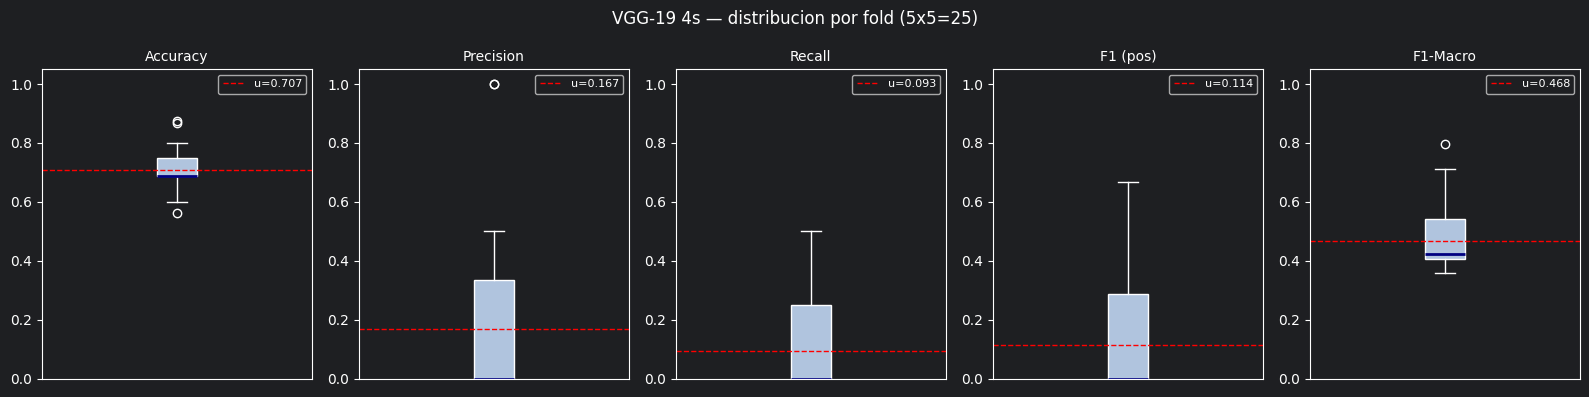

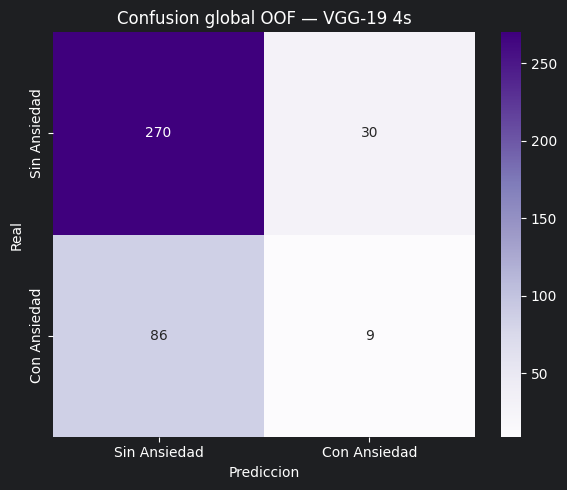

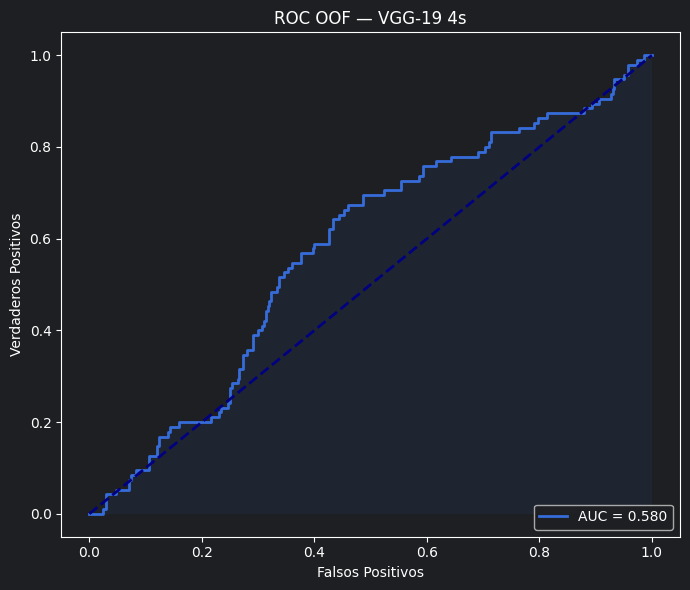

Archivos guardados en: Ansiedad/VGG19/4s


In [14]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  VGG-19 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 4s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/4s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 4
BATCH_SIZE  = 64
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "VGG-19"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("VGG19/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.vgg19_bn(weights=tv_models.VGG19_BN_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Linear(m.classifier[0].in_features, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



# EfficientNet-B0

## 10 s | Sin overlap

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/EfficientNet/10s
  Modelo : EfficientNet-B0 | 10s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 1,813  |  prom 22.9 segs/audio
  Guardando resultados en: Ansiedad/EfficientNet/10s

INICIANDO REPEATED CV — EfficientNet-B0 | 10s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 2,235
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/ci2dt2-ai/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 85.0MB/s]

  Parametros entrenables: 4,171,645



  Ep 01/30 loss 0.6817  best 0.6817  ✓
  Ep 02/30 loss 0.6194  best 0.6194  ✓
  Ep 03/30 loss 0.4539  best 0.4539  ✓
  Ep 04/30 loss 0.2486  best 0.2486  ✓
  Ep 05/30 loss 0.1411  best 0.1411  ✓
  Ep 06/30 loss 0.0733  best 0.0733  ✓
  Ep 07/30 loss 0.0550  best 0.0550  ✓
  Ep 08/30 loss 0.0391  best 0.0391  ✓
  Ep 09/30 loss 0.0311  best 0.0311  ✓
  Ep 10/30 loss 0.0291  best 0.0291  ✓
  Ep 11/30 loss 0.0179  best 0.0179  ✓
  Ep 12/30 loss 0.0235  best 0.0179  (1/5)
  Ep 13/30 loss 0.0248  best 0.0179  (2/5)
  Ep 14/30 loss 0.0230  best 0.0179  (3/5)
  Ep 15/30 loss 0.0112  best 0.0112  ✓
  Ep 16/30 loss 0.0194  best 0.0112  (1/5)
  Ep 17/30 loss 0.0173  best 0.0112  (2/5)
  Ep 18/30 loss 0.0239  best 0.0112  (3/5)
  Ep 19/30 loss 0.0167  best 0.0112  (4/5)
  Ep 20/30 loss 0.0204  best 0.0112  (5/5)
  ► Early stopping.
  -> Fold acc=0.562  prec=0.000  rec=0.000  F1=0.000  F1-mac=0.360

────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 2/5  [2/25]
────────

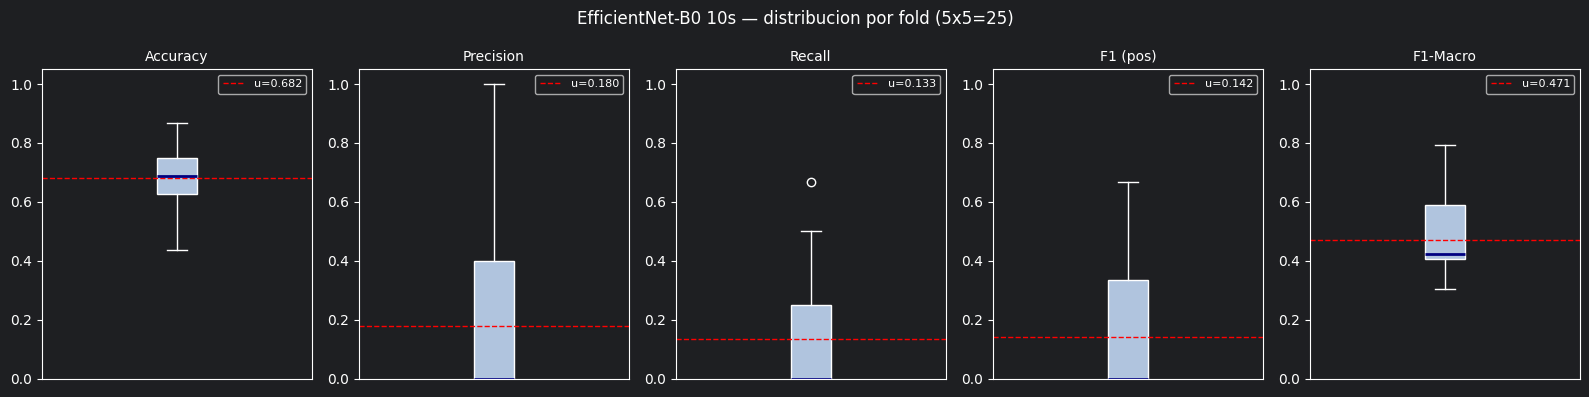

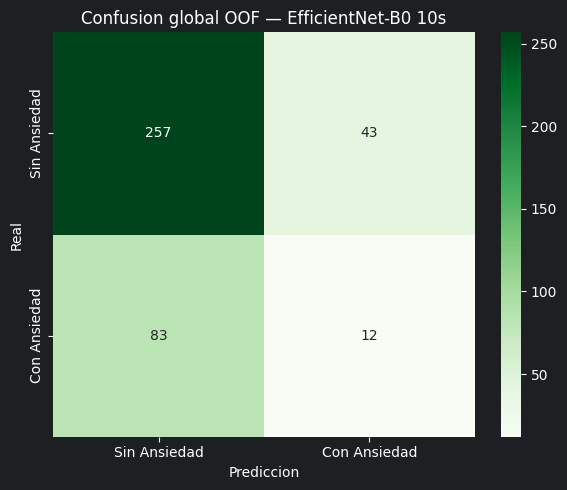

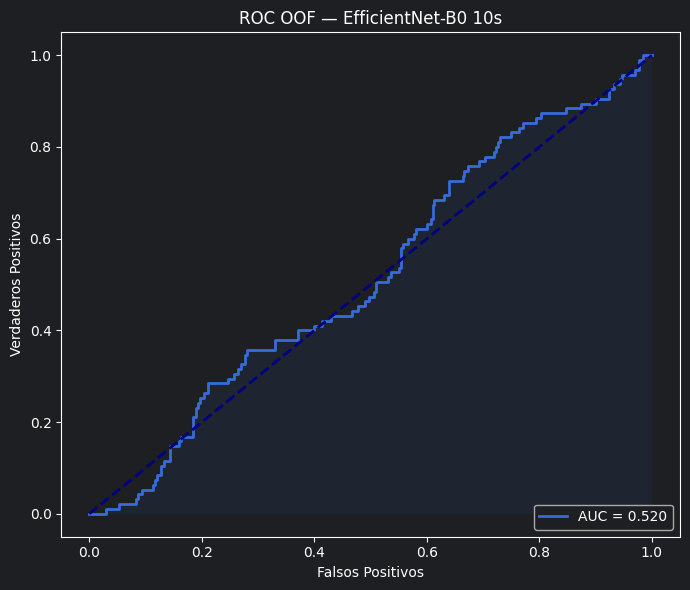

Archivos guardados en: Ansiedad/EfficientNet/10s


In [15]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  EfficientNet-B0 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 10s | 0% (sin overlap)
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/10s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 10
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(m.classifier[1].in_features, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 2 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/EfficientNet/2s
  Modelo : EfficientNet-B0 | 2s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 18,369  |  prom 232.5 segs/audio
  Guardando resultados en: Ansiedad/EfficientNet/2s

INICIANDO REPEATED CV — EfficientNet-B0 | 2s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 21,963
  Parametros entrenables: 4,171,645

  Ep 01/30 loss 0.5637  best 0.5637  ✓
  Ep 02/30 loss 0.3095  best 0.3095  ✓
  Ep 03/30 loss 0.1787  best 0.1787  ✓
  Ep 04/30 loss 0.1127  best 0.1127  ✓
  Ep 05/30 loss 0.0797  best 0.0797  ✓
  Ep 06/30 loss 0.0586  best 0.0586  ✓
  Ep 07/30 loss 0.0504  best 0.0504  ✓
  Ep 08/30 loss 0.0386  best 0.0386  ✓
  Ep 09/30 loss 0.0330  best 0.033

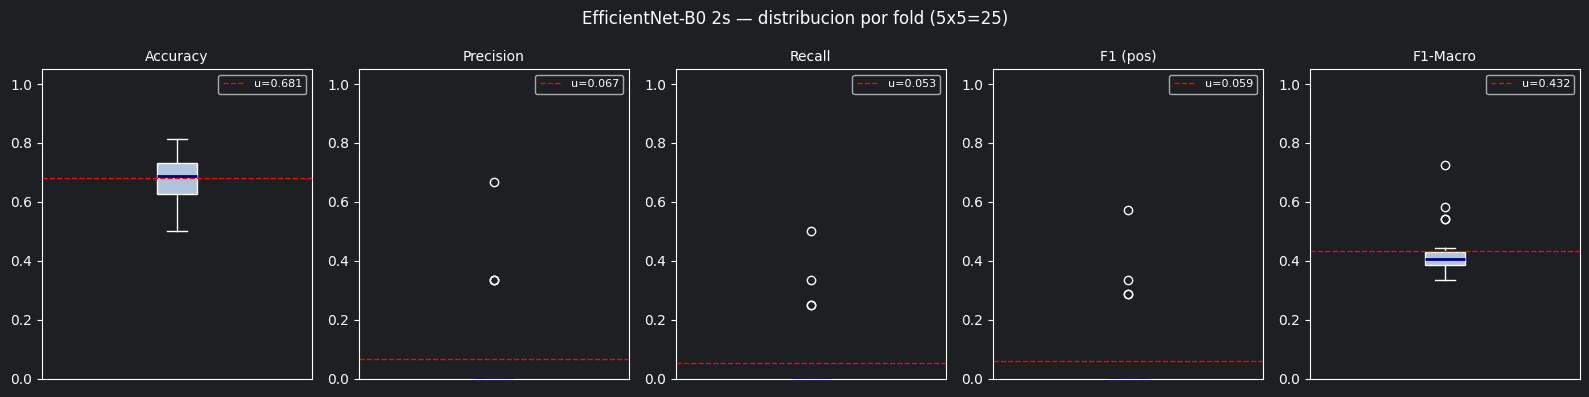

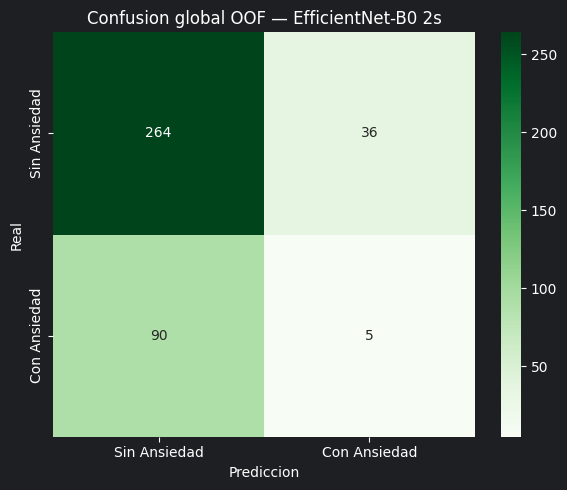

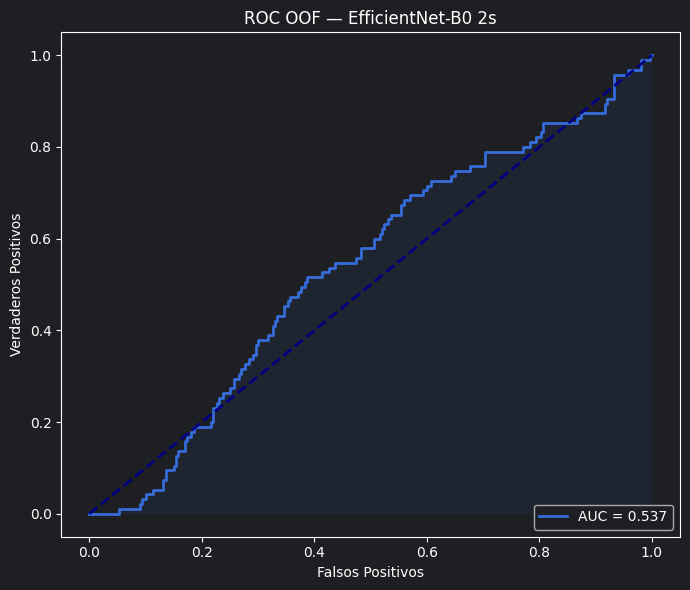

Archivos guardados en: Ansiedad/EfficientNet/2s


In [16]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  EfficientNet-B0 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 2s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/2s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 2
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/2s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(m.classifier[1].in_features, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 3 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/EfficientNet/3s
  Modelo : EfficientNet-B0 | 3s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 12,202  |  prom 154.5 segs/audio
  Guardando resultados en: Ansiedad/EfficientNet/3s

INICIANDO REPEATED CV — EfficientNet-B0 | 3s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 15,286
  Parametros entrenables: 4,171,645

  Ep 01/30 loss 0.5701  best 0.5701  ✓
  Ep 02/30 loss 0.2835  best 0.2835  ✓
  Ep 03/30 loss 0.1503  best 0.1503  ✓
  Ep 04/30 loss 0.0947  best 0.0947  ✓
  Ep 05/30 loss 0.0550  best 0.0550  ✓
  Ep 06/30 loss 0.0481  best 0.0481  ✓
  Ep 07/30 loss 0.0385  best 0.0385  ✓
  Ep 08/30 loss 0.0331  best 0.0331  ✓
  Ep 09/30 loss 0.0282  best 0.028

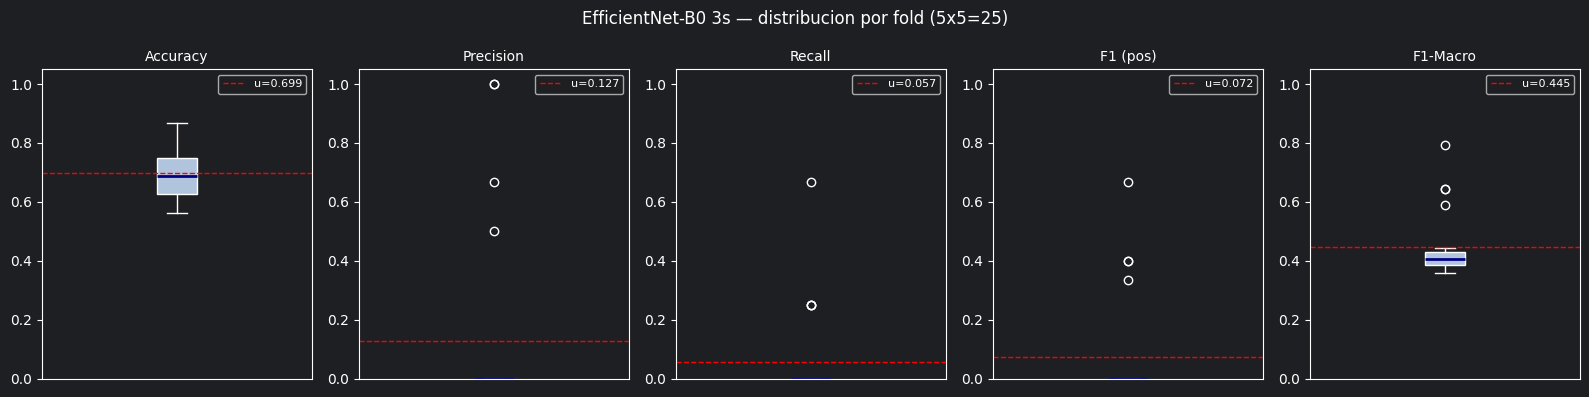

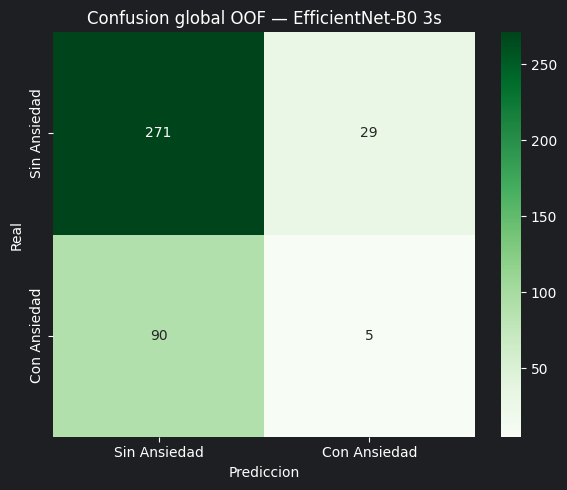

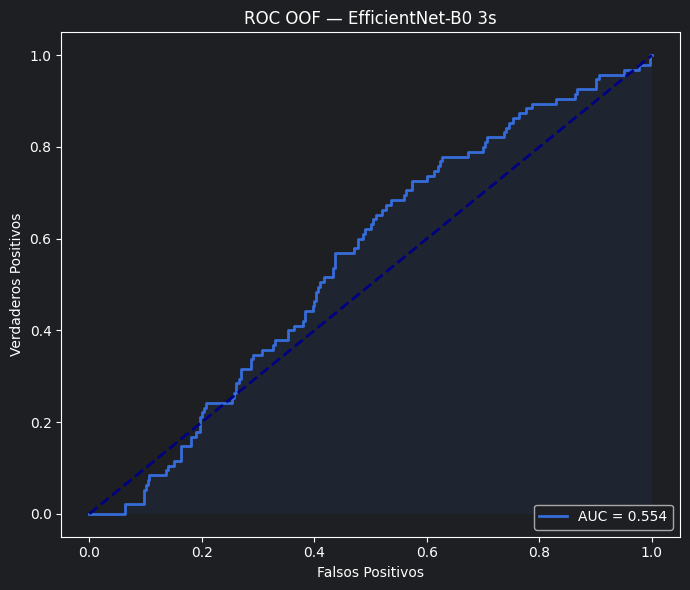

Archivos guardados en: Ansiedad/EfficientNet/3s


In [17]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  EfficientNet-B0 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 3s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/3s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 3
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/3s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(m.classifier[1].in_features, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")



## 4 s | Overlap 50%

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 5080
  Guardando resultados en: Ansiedad/EfficientNet/4s
  Modelo : EfficientNet-B0 | 4s | 5-Fold x 5 reps = 25 folds

Archivos originales: 79
  Clase 0 (Sin Ansiedad): 60
  Clase 1 (Con Ansiedad): 19
  Total imagenes: 9,127  |  prom 115.5 segs/audio
  Guardando resultados en: Ansiedad/EfficientNet/4s

INICIANDO REPEATED CV — EfficientNet-B0 | 4s
5-Fold x 5 repeticiones = 25 folds totales


────────────────────────────────────────────────────────────
  Rep 1/5  |  Fold 1/5  [1/25]
────────────────────────────────────────────────────────────
  Imagenes train: 11,242
  Parametros entrenables: 4,171,645

  Ep 01/30 loss 0.5905  best 0.5905  ✓
  Ep 02/30 loss 0.3002  best 0.3002  ✓
  Ep 03/30 loss 0.1678  best 0.1678  ✓
  Ep 04/30 loss 0.1116  best 0.1116  ✓
  Ep 05/30 loss 0.0752  best 0.0752  ✓
  Ep 06/30 loss 0.0568  best 0.0568  ✓
  Ep 07/30 loss 0.0439  best 0.0439  ✓
  Ep 08/30 loss 0.0661  best 0.0439  (1/5)
  Ep 09/30 loss 0.0364  best 0.

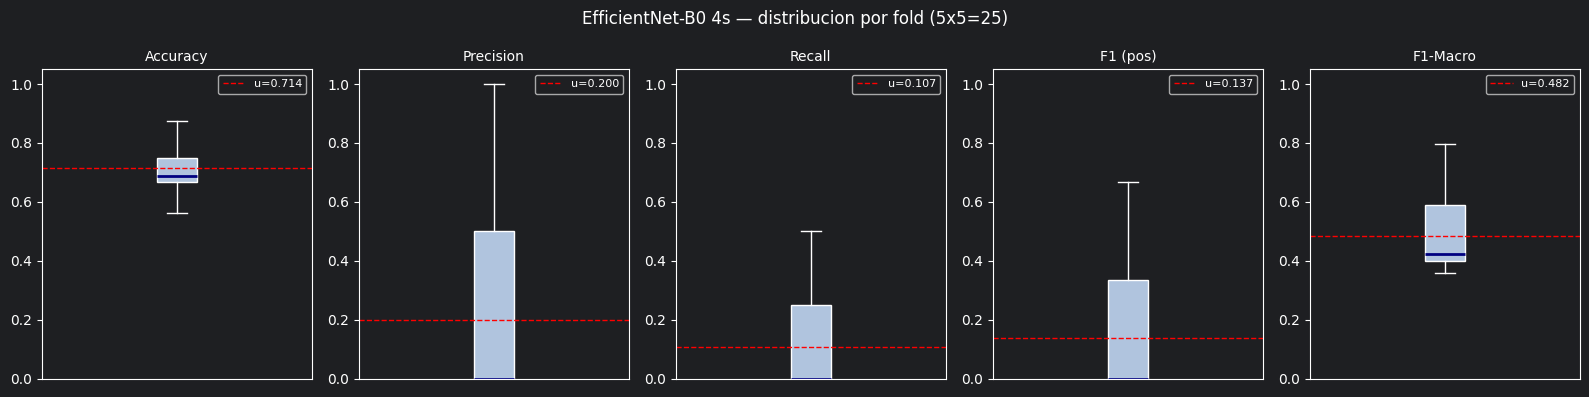

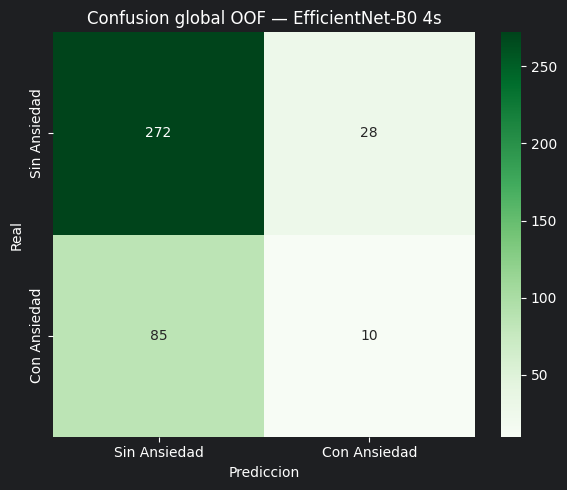

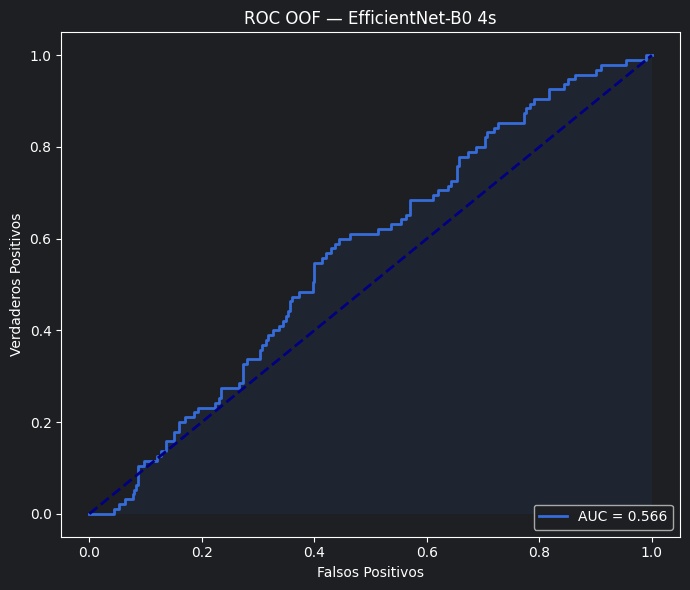

Archivos guardados en: Ansiedad/EfficientNet/4s


In [18]:
import os, gc, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
from sklearn.utils import class_weight



# ══════════════════════════════════════════════════════════════
#  EfficientNet-B0 — Log-Mel Spectrogram 2D  [PyTorch | CUDA]
#  Segmentos 4s | 50%
#  Repeated Stratified 5-Fold CV × 5 repeticiones = 25 folds
# ══════════════════════════════════════════════════════════════

CONDITION  = "Ansiedad"
IMAGE_ROOT = Path("../../Clasificación Final/Ansiedad/specs/log-mel/4s")

N_SPLITS    = 5
N_REPEATS   = 5
SEGMENT_DUR = 4
BATCH_SIZE  = 96
EPOCHS      = 30
IMG_H       = 224
IMG_W       = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")
print(f"  Modelo : {MODEL_NAME} | {SEGMENT_DUR}s | "
      f"{N_SPLITS}-Fold x {N_REPEATS} reps = {N_SPLITS*N_REPEATS} folds")



# =============================================================================
# DATASET — split a nivel de ARCHIVO ORIGINAL para evitar data leakage
# =============================================================================

def build_file_index(root: Path):
    img_map    = {}
    stem_label = {}
    for cls_str in ["0", "1"]:
        d = root / cls_str
        if not d.exists():
            print(f"  [AVISO] No existe: {d}"); continue
        for p in sorted(d.glob("*.png")):
            stem = re.sub(r'_seg\d+$', '', p.stem)
            img_map.setdefault(stem, []).append(p)
            stem_label[stem] = int(cls_str)
    stems  = sorted(img_map.keys())
    labels = np.array([stem_label[s] for s in stems], dtype=np.int64)
    return stems, labels, img_map

file_stems, file_labels, img_map = build_file_index(IMAGE_ROOT)
print(f"\nArchivos originales: {len(file_stems)}")
print(f"  Clase 0 (Sin {CONDITION}): {int((file_labels==0).sum())}")
print(f"  Clase 1 (Con {CONDITION}): {int((file_labels==1).sum())}")
total_imgs = sum(len(v) for v in img_map.values())
print(f"  Total imagenes: {total_imgs:,}  |  prom {total_imgs/len(file_stems):.1f} segs/audio")

TRANSFORM_TRAIN = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
TRANSFORM_VAL = T.Compose([
    T.Resize((IMG_H, IMG_W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SpectrogramDataset(Dataset):
    def __init__(self, stems, img_map, transform):
        self.samples = []
        for stem in stems:
            for p in img_map[stem]:
                self.samples.append((p, int(p.parent.name)))
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(label, dtype=torch.long)

def oversample_stems(stems, labels):
    stems  = np.array(stems)
    s1     = stems[labels == 1]
    diff   = int((labels == 0).sum()) - int((labels == 1).sum())
    if diff > 0:
        idx    = np.random.choice(len(s1), size=diff, replace=True)
        stems  = np.concatenate([stems, s1[idx]])
        labels = np.concatenate([labels, labels[labels == 1][idx]])
    return list(stems), labels



MODEL_NAME = "EfficientNet-B0"

# ── Carpeta de salida ────────────────────────────────────────────────────
OUT_DIR = Path("EfficientNet/4s")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Guardando resultados en: {OUT_DIR}")

def build_model():
    m = tv_models.efficientnet_b0(
            weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(m.classifier[1].in_features, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
        nn.Linear(128, 1), nn.Sigmoid()
    )
    return m



def train_one_epoch(model, loader, optimizer, criterion, cw_tensor):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)
        preds = model(xb).view(-1)

        sample_w = cw_tensor[yb.long()]
        loss = (criterion(preds, yb) * sample_w).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def predict_stems(model, stems, img_map, transform):
    """Segment voting con DataLoader — evita timeout de CUDA."""
    model.eval()

    class StemDataset(Dataset):
        def __init__(self, stems, img_map, transform):
            self.samples = []
            for stem in stems:
                for p in img_map[stem]:
                    self.samples.append((stem, p))
            self.transform = transform
        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            stem, path = self.samples[idx]
            img = Image.open(path).convert("RGB")
            return self.transform(img), stem

    ds = StemDataset(stems, img_map, transform)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=8, pin_memory=True)

    probs_by_stem = {s: [] for s in stems}
    with torch.no_grad():
        for xb, stem_names in dl:
            xb  = xb.to(DEVICE, non_blocking=True)
            out = model(xb).view(-1).cpu().numpy()

            for prob, stem in zip(out, stem_names):
                probs_by_stem[stem].append(float(prob))

    return {stem: float(np.mean(probs)) for stem, probs in probs_by_stem.items()}



rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

file_stems_arr = np.array(file_stems)
global_y_true, global_y_pred, global_y_prob = [], [], []
fold_metrics = []
total_folds  = N_SPLITS * N_REPEATS
fold_global  = 0

print(f"\nINICIANDO REPEATED CV — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {total_folds} folds totales\n")

for fold_idx, (tr_idx, te_idx) in enumerate(
        rskf.split(file_stems_arr, file_labels)):

    repeat_n = fold_idx // N_SPLITS + 1
    fold_n   = fold_idx %  N_SPLITS + 1
    fold_global += 1

    print(f"\n{'─'*60}")
    print(f"  Rep {repeat_n}/{N_REPEATS}  |  Fold {fold_n}/{N_SPLITS}  "
          f"[{fold_global}/{total_folds}]")
    print(f"{'─'*60}")

    tr_stems  = list(file_stems_arr[tr_idx])
    te_stems  = list(file_stems_arr[te_idx])
    tr_labels = file_labels[tr_idx]
    te_labels = file_labels[te_idx]

    tr_stems, tr_labels = oversample_stems(tr_stems, tr_labels)

    train_ds = SpectrogramDataset(tr_stems, img_map, TRANSFORM_TRAIN)
    train_dl = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=8, pin_memory=True, persistent_workers=True,
        prefetch_factor=2,
    )
    print(f"  Imagenes train: {len(train_ds):,}")

    weights   = class_weight.compute_class_weight(
                    'balanced', classes=np.unique(tr_labels), y=tr_labels)
    cw_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    model     = build_model().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss(reduction='none')
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, 'min', factor=0.5, patience=3, min_lr=1e-7)

    if fold_idx == 0:
        n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Parametros entrenables: {n_p:,}\n")

    best_loss, patience_cnt, PATIENCE, best_state = float('inf'), 0, 5, None
    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_dl, optimizer, criterion, cw_tensor)
        scheduler.step(loss)
        if loss < best_loss:
            best_loss = loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            mark = "✓"
        else:
            patience_cnt += 1; mark = f"({patience_cnt}/{PATIENCE})"
        print(f"  Ep {epoch+1:02d}/{EPOCHS} loss {loss:.4f}  "
              f"best {best_loss:.4f}  {mark}")
        if patience_cnt >= PATIENCE:
            print("  ► Early stopping."); break

    model.load_state_dict(best_state)

    stem_probs = predict_stems(model, te_stems, img_map, TRANSFORM_VAL)

    fold_true, fold_pred, fold_prob = [], [], []
    for stem, lbl in zip(te_stems, te_labels):
        prob = stem_probs[stem]
        pred = 1 if prob > 0.33 else 0
        global_y_true.append(int(lbl))
        global_y_pred.append(pred)
        global_y_prob.append(prob)
        fold_true.append(int(lbl))
        fold_pred.append(pred)
        fold_prob.append(prob)

    fold_metrics.append({
        "rep"   : repeat_n,
        "fold"  : fold_n,
        "acc"   : accuracy_score(fold_true, fold_pred),
        "prec"  : precision_score(fold_true, fold_pred, zero_division=0),
        "rec"   : recall_score(fold_true, fold_pred, zero_division=0),
        "f1"    : f1_score(fold_true, fold_pred, zero_division=0),
        "f1mac" : f1_score(fold_true, fold_pred, average='macro', zero_division=0),
    })
    m = fold_metrics[-1]
    print(f"  -> Fold acc={m['acc']:.3f}  prec={m['prec']:.3f}  "
          f"rec={m['rec']:.3f}  F1={m['f1']:.3f}  F1-mac={m['f1mac']:.3f}")

    del model, train_ds, train_dl, best_state, cw_tensor
    gc.collect(); torch.cuda.empty_cache()



# =============================================================================
# REPORTE FINAL
# =============================================================================

print("\n" + "="*65)
print(f"RESULTADOS FINALES — {MODEL_NAME} | {SEGMENT_DUR}s")
print(f"{N_SPLITS}-Fold x {N_REPEATS} repeticiones = {N_SPLITS*N_REPEATS} folds")
print("="*65)

metrics_arr = {
    k: np.array([d[k] for d in fold_metrics])
    for k in ["acc","prec","rec","f1","f1mac"]
}
labels_m = {"acc":"Accuracy","prec":"Precision","rec":"Recall",
             "f1":"F1 (pos)","f1mac":"F1-Macro"}

print("\nMetricas por fold:")
print(f"  {'Rep-Fold':10s}  Acc    Prec   Rec    F1     F1-Mac")
for d in fold_metrics:
    print(f"  R{d['rep']:02d}-F{d['fold']:02d}     "
          f"{d['acc']:.3f}  {d['prec']:.3f}  {d['rec']:.3f}  "
          f"{d['f1']:.3f}  {d['f1mac']:.3f}")

print("\n" + "-"*55)
print(f"  {'MEDIA':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].mean():.3f}  ", end="")
print()
print(f"  {'± STD':10s}  ", end="")
for k in ["acc","prec","rec","f1","f1mac"]:
    print(f"{metrics_arr[k].std():.3f}  ", end="")
print()

acc_g  = accuracy_score(global_y_true, global_y_pred)
prec_g = precision_score(global_y_true, global_y_pred, zero_division=0)
rec_g  = recall_score(global_y_true, global_y_pred, zero_division=0)
f1_g   = f1_score(global_y_true, global_y_pred, zero_division=0)
f1m_g  = f1_score(global_y_true, global_y_pred, average='macro', zero_division=0)
print(f"\nReporte global OOF:")
print(f"  Accuracy : {acc_g:.4f}")
print(f"  Precision: {prec_g:.4f}")
print(f"  Recall   : {rec_g:.4f}")
print(f"  F1 (pos) : {f1_g:.4f}")
print(f"  F1-Macro : {f1m_g:.4f}")
print()
print(classification_report(global_y_true, global_y_pred,
      target_names=['Sin '+CONDITION, 'Con '+CONDITION]))

fname = MODEL_NAME.replace(' ','_').replace('-','').lower()

# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle(f"{MODEL_NAME} {SEGMENT_DUR}s — distribucion por fold "
             f"({N_SPLITS}x{N_REPEATS}={N_SPLITS*N_REPEATS})", fontsize=12)
for ax, (k, label) in zip(axes, labels_m.items()):
    ax.boxplot(metrics_arr[k], patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.axhline(metrics_arr[k].mean(), color='red', linestyle='--',
               linewidth=1, label=f"u={metrics_arr[k].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f'boxplot_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# Confusion matrix
cm = confusion_matrix(global_y_true, global_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin '+CONDITION, 'Con '+CONDITION],
            yticklabels=['Sin '+CONDITION, 'Con '+CONDITION])
plt.title(f'Confusion global OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.ylabel('Real'); plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig(OUT_DIR / f'confusion_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()

# ROC
fpr, tpr, _ = roc_curve(global_y_true, global_y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'navy',lw=2,linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.08)
plt.xlabel('Falsos Positivos'); plt.ylabel('Verdaderos Positivos')
plt.title(f'ROC OOF — {MODEL_NAME} {SEGMENT_DUR}s')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(OUT_DIR / f'roc_{fname}_{SEGMENT_DUR}s.png', dpi=150)
plt.show()
print(f"Archivos guardados en: {OUT_DIR}")

